# Customer Churn Prediction - EDA and Modeling\n
\n
This notebook starts with **Step 1: Exploratory Data Analysis (EDA)** for the Telco Customer Churn dataset.

In [2]:
# Import core libraries for data loading and visualization
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use a consistent visual style for plots
sns.set(style="whitegrid", context="notebook")

# Build a robust path to the dataset relative to this notebook
DATA_PATH = Path("..") / "data" / "telco_churn.csv"
df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset from: {DATA_PATH.resolve()}")

Loaded dataset from: D:\Projects\AI-ML projects\churn_predictor\churn-prediction\data\telco_churn.csv


In [4]:
# Show dataset shape
print("Shape:", df.shape)

# Show data types for all columns
print("\nData types:")
print(df.dtypes)

# Show missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

# Preview the first few rows
df.head()

Shape: (7043, 21)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


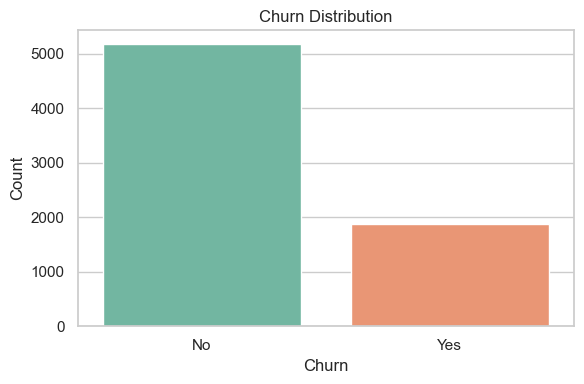

In [9]:
# Plot overall churn distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2")
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
# Fix TotalCharges because it is commonly read as string with blank spaces
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Confirm conversion and inspect nulls created from invalid values
print("TotalCharges dtype after conversion:", df["TotalCharges"].dtype)
print("TotalCharges missing values after conversion:", df["TotalCharges"].isnull().sum())

TotalCharges dtype after conversion: float64
TotalCharges missing values after conversion: 11


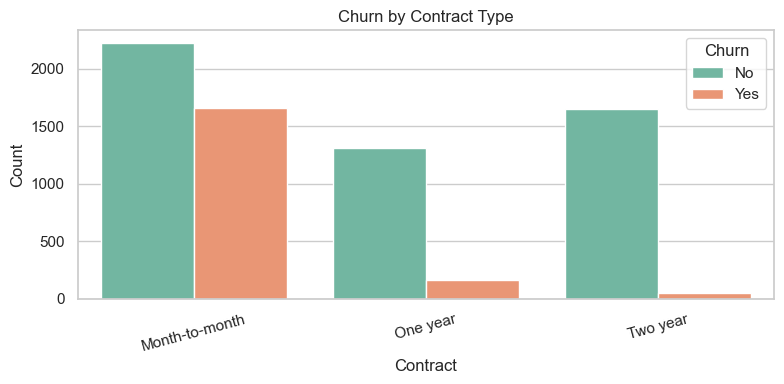

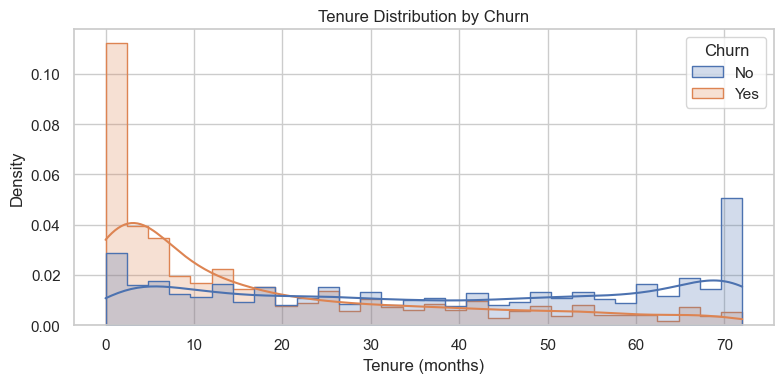

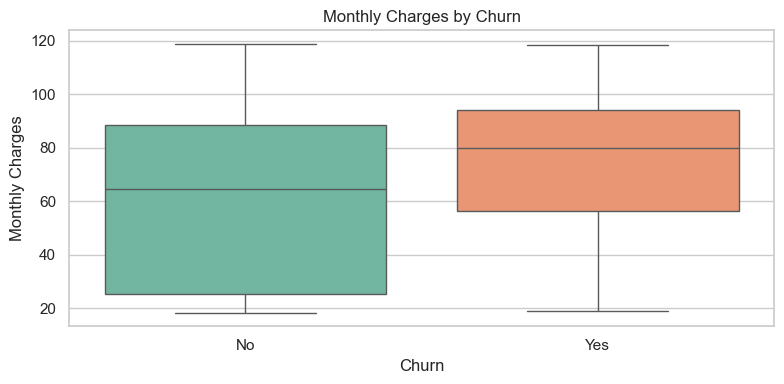

In [10]:
# Plot churn by contract type
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot tenure distribution by churn
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, element="step", stat="density", common_norm=False)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Plot monthly charges by churn
plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette="Set2")
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

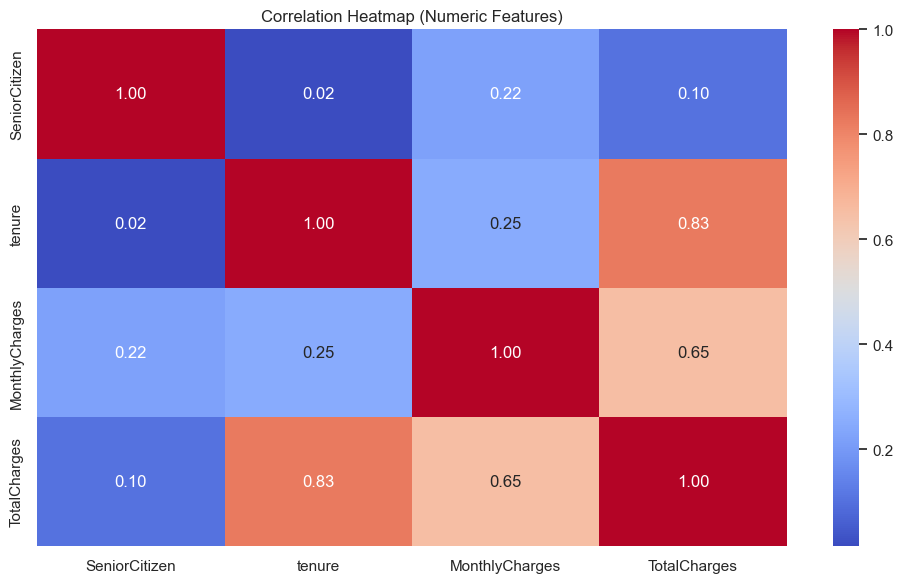

In [8]:
# Select numeric columns and visualize pairwise correlations
numeric_df = df.select_dtypes(include=["number"]).copy()

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

## Step 2 - Preprocessing
This section prepares model-ready data by cleaning columns, encoding the target, splitting train/test sets, and building a reusable sklearn preprocessing pipeline.

In [3]:
# Import preprocessing utilities from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Create a clean working copy so EDA dataframe remains unchanged
df_model = df.copy()

# Fix TotalCharges: convert to numeric and fill invalid/missing values with median
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(df_model["TotalCharges"].median())

# Encode target: Yes -> 1, No -> 0
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID and split into features/target
X = df_model.drop(columns=["customerID", "Churn"])
y = df_model["Churn"]

# Identify numeric and categorical feature sets
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Create reproducible train/test split with class stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Build preprocessing transformer to scale numeric and one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

# Wrap preprocessor in a pipeline for clean reuse with future models
preprocess_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
    ]
)

# Fit on training data only, then transform train and test sets
X_train_processed = preprocess_pipeline.fit_transform(X_train)
X_test_processed = preprocess_pipeline.transform(X_test)

# Store transformed feature names for model interpretation and app integration
feature_cols = preprocess_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Print key artifacts to verify preprocessing outcomes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_test shape: {X_test_processed.shape}")
print(f"Target distribution (train):\n{y_train.value_counts(normalize=True)}")
print(f"Number of output features after encoding: {len(feature_cols)}")

X_train shape: (5634, 19)
X_test shape: (1409, 19)
Processed X_train shape: (5634, 30)
Processed X_test shape: (1409, 30)
Target distribution (train):
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Number of output features after encoding: 30


## Step 3 - Train and Compare Models
Train three classifiers, evaluate them with F1-focused reports and ROC-AUC, and plot all ROC curves in one figure.


Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0      0.849     0.895     0.871      1035
           1      0.657     0.559     0.604       374

    accuracy                          0.806      1409
   macro avg      0.753     0.727     0.738      1409
weighted avg      0.798     0.806     0.800      1409

ROC-AUC: 0.8420
F1-score: 0.6040

Random Forest
Classification Report:
              precision    recall  f1-score   support

           0      0.829     0.892     0.859      1035
           1      0.622     0.492     0.549       374

    accuracy                          0.786      1409
   macro avg      0.725     0.692     0.704      1409
weighted avg      0.774     0.786     0.777      1409

ROC-AUC: 0.8246
F1-score: 0.5493

Gradient Boosting
Classification Report:
              precision    recall  f1-score   support

           0      0.837     0.901     0.868      1035
           1      0.653     0.513     0.575    

,Model,F1,ROC_AUC
0,Logistic Regression,0.604046,0.842006
1,Gradient Boosting,0.574850,0.842094
2,Random Forest,0.549254,0.824645



Best model selected for next steps: Logistic Regression


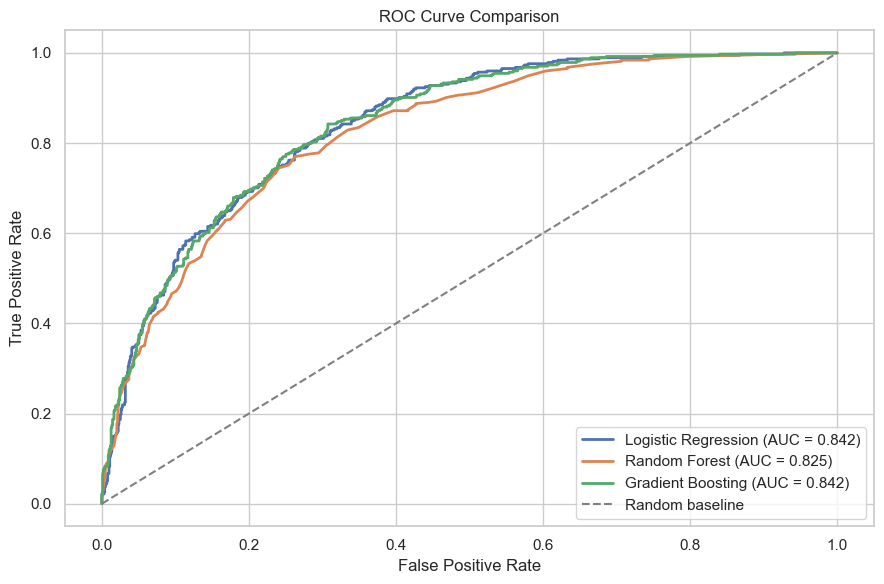

In [4]:
# Import model and evaluation utilities
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score

# Convert sparse matrices to dense when needed for model compatibility
X_train_final = X_train_processed.toarray() if sparse.issparse(X_train_processed) else X_train_processed
X_test_final = X_test_processed.toarray() if sparse.issparse(X_test_processed) else X_test_processed

# Define candidate models with reproducible random_state settings
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

# Train each model, print classification report + ROC-AUC, and store results
model_results = []
trained_models = {}
roc_curves = {}

for model_name, model in models.items():
    # Fit the model and generate class predictions/probabilities
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    y_proba = model.predict_proba(X_test_final)[:, 1]

    # Compute primary metrics for comparison
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Print detailed classification metrics
    print(f"\n{'=' * 60}")
    print(f"{model_name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Save artifacts for downstream steps
    trained_models[model_name] = model
    model_results.append({"Model": model_name, "F1": f1, "ROC_AUC": roc_auc})
    roc_curves[model_name] = roc_curve(y_test, y_proba)

# Summarize model ranking by F1 first, then ROC-AUC
results_df = pd.DataFrame(model_results).sort_values(by=["F1", "ROC_AUC"], ascending=False).reset_index(drop=True)
print("\nModel ranking (primary: F1, secondary: ROC-AUC):")
display(results_df)

# Select the best model for the next steps
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
print(f"\nBest model selected for next steps: {best_model_name}")

# Plot ROC curves for all models on one chart
plt.figure(figsize=(9, 6))
for model_name, (fpr, tpr, _) in roc_curves.items():
    model_auc = results_df.loc[results_df["Model"] == model_name, "ROC_AUC"].values[0]
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {model_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Step 4 - Feature Importance
Extract top 10 feature importances from the selected best model and save the plot for app usage.

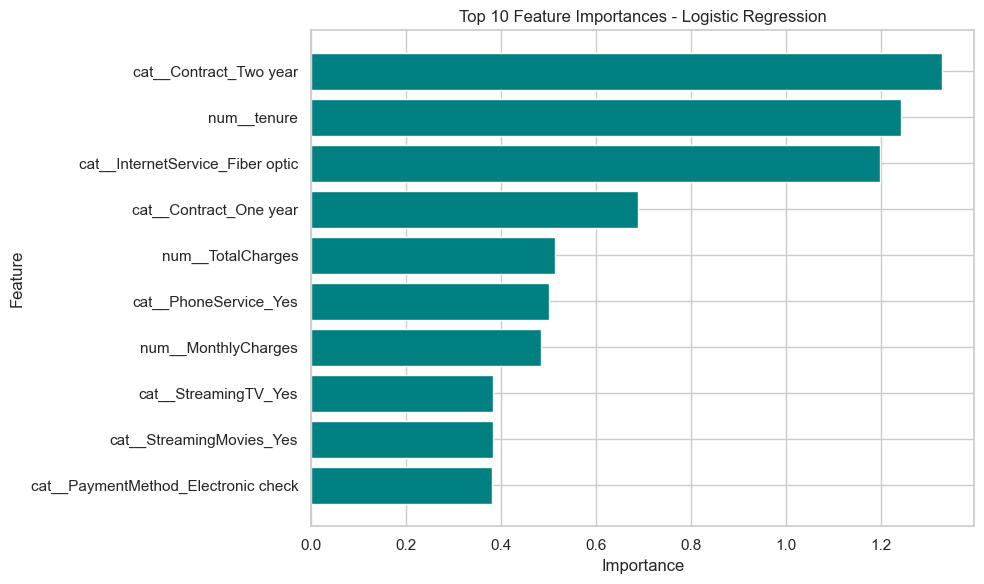

Feature importance plot saved to: D:\Projects\AI-ML projects\churn_predictor\churn-prediction\feature_importance.png


,feature,importance
0,cat__Contract_Two year,1.330086
1,num__tenure,1.242460
2,cat__InternetService_Fiber optic,1.198969
3,cat__Contract_One year,0.687821
4,num__TotalCharges,0.513307
5,cat__PhoneService_Yes,0.501797
6,num__MonthlyCharges,0.484459
7,cat__StreamingTV_Yes,0.383166
8,cat__StreamingMovies_Yes,0.382559
9,cat__PaymentMethod_Electronic check,0.381118


In [4]:
# Import helper libraries for feature importance plotting
from pathlib import Path
import numpy as np

# Create a feature-importance series from the selected best model
if hasattr(best_model, "feature_importances_"):
    # Tree-based models expose feature_importances_ directly
    importance_values = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    # Linear models use coefficient magnitude as feature importance
    importance_values = np.abs(best_model.coef_).ravel()
else:
    raise ValueError(f"Selected model '{best_model_name}' does not provide feature importances or coefficients.")

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": importance_values,
    }
).sort_values("importance", ascending=False)

# Select top 10 important features for visualization
top10_importance = feature_importance_df.head(10).sort_values("importance", ascending=True)

# Plot and save the feature importance chart
plt.figure(figsize=(10, 6))
plt.barh(top10_importance["feature"], top10_importance["importance"], color="teal")
plt.title(f"Top 10 Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

feature_plot_path = Path("..") / "feature_importance.png"
plt.savefig(feature_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Feature importance plot saved to: {feature_plot_path.resolve()}")
display(top10_importance.sort_values("importance", ascending=False).reset_index(drop=True))

## Step 5 - Save Model Artifacts
Save the selected best model and encoded feature column names for use in the Streamlit prediction app.

In [5]:
# Import joblib for artifact persistence
import joblib
from pathlib import Path

# Define output paths in the project root directory
PROJECT_ROOT = Path("..")
model_output_path = PROJECT_ROOT / "model.pkl"
feature_cols_output_path = PROJECT_ROOT / "feature_cols.pkl"

# Save trained best model and encoded feature columns
joblib.dump(best_model, model_output_path)
joblib.dump(feature_cols, feature_cols_output_path)

# Print saved artifact locations for verification
print(f"Saved model to: {model_output_path.resolve()}")
print(f"Saved feature columns to: {feature_cols_output_path.resolve()}")
print(f"Total saved feature columns: {len(feature_cols)}")

Saved model to: D:\Projects\AI-ML projects\churn_predictor\churn-prediction\model.pkl
Saved feature columns to: D:\Projects\AI-ML projects\churn_predictor\churn-prediction\feature_cols.pkl
Total saved feature columns: 30
